# Apple Dataset

**Features**:
1. A_id
2. Size
3. Weight
4. Sweetness
5. Crunchiness
6. Juiciness
7. Ripeness
8. Acidity
9. Quality 

![imagen](https://storage.googleapis.com/kaggle-datasets-images/4291772/7384155/168acfd1f6ff796e7d9cd23602494f15/dataset-cover.jpeg?t=2024-01-11-14-32-08)


In [3]:
# Importacion de librerias necesarias
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Configuración de numpy para mejor visualización
np.set_printoptions(suppress=True, precision=3)

# Carga de datos numéricos ignorando cabecera y pie
datos_num = np.genfromtxt("./apple_quality.csv", delimiter=",", skip_header=1, skip_footer=1)
print("Vista de datos numéricos:\n", datos_num[:3]) # Imprimir solo primeras filas para no saturar

print("----------------------------------------------")

# Carga de datos como texto para extraer la columna de clases
datos_texto = np.genfromtxt("./apple_quality.csv", delimiter=",", dtype=str, skip_header=1, skip_footer=1)

Vista de datos numéricos:
 [[ 0.    -3.97  -2.512  5.346 -1.012  1.845  0.33  -0.492    nan]
 [ 1.    -1.195 -2.839  3.664  1.588  0.853  0.868 -0.723    nan]
 [ 2.    -0.292 -1.351 -1.738 -0.343  2.839 -0.038  2.622    nan]]
----------------------------------------------


Seleccionamos las variables(x) y las etiquetas (y):
- x tiene las caracteristicas numericas de cada manzana
- y contiene la calidad, lo que esperamos predecir si es good or bad

In [5]:
# X representa las variables independientes, Y la variable dependiente (objetivo)
X = datos_num[:, :-1]
Y_labels = datos_texto[:, -1]

print("Primeras etiquetas:", Y_labels[:5])

Primeras etiquetas: ['good' 'good' 'bad' 'good' 'good']


Transformación de etiquetas y división del dataset empleando *Scikit-Learn*.

In [6]:
from sklearn.model_selection import train_test_split

# Convertimos las etiquetas de texto a valores binarios de forma vectorizada con numpy
Y_numerico = np.where(Y_labels == 'good', 1, 0)

Dividiremos el conjunto de datos asignando un **30% a validación (test)** y manteniendo el **70% para entrenamiento**. Usaremos una semilla aleatoria para asegurar reproducibilidad.

In [7]:
# Division de datos usando sklearn
X_train, X_test, y_train, y_test = train_test_split(X, Y_numerico, test_size=0.3, random_state=42)

print(f"Set de entrenamiento (X): {X_train.shape}")
print(f"Set de prueba (X): {X_test.shape}")

Set de entrenamiento (X): (2800, 8)
Set de prueba (X): (1200, 8)


#### Arbol de decision

-> Precisión global del Árbol de Decisión: 0.7308



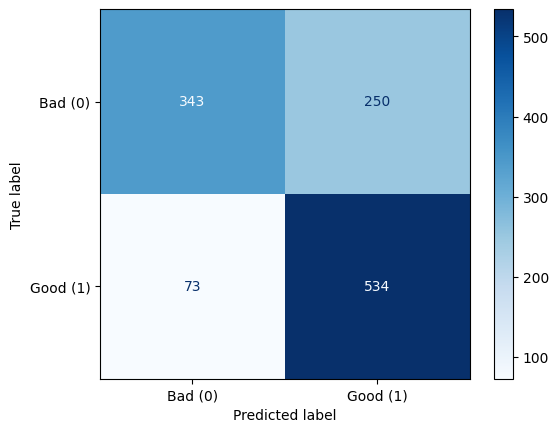

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

# Inicializar y entrenar el modelo limitando su expansión
modelo_arbol = DecisionTreeClassifier(max_depth=4, random_state=42) 
modelo_arbol.fit(X_train, y_train)

# Predicción sobre los datos de test
pred = modelo_arbol.predict(X_test)
acc = accuracy_score(y_test, pred)
print(f"-> Precisión global del Árbol de Decisión: {acc:.4f}\n")

# Mostrar matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=['Bad (0)', 'Good (1)'], cmap='Blues')

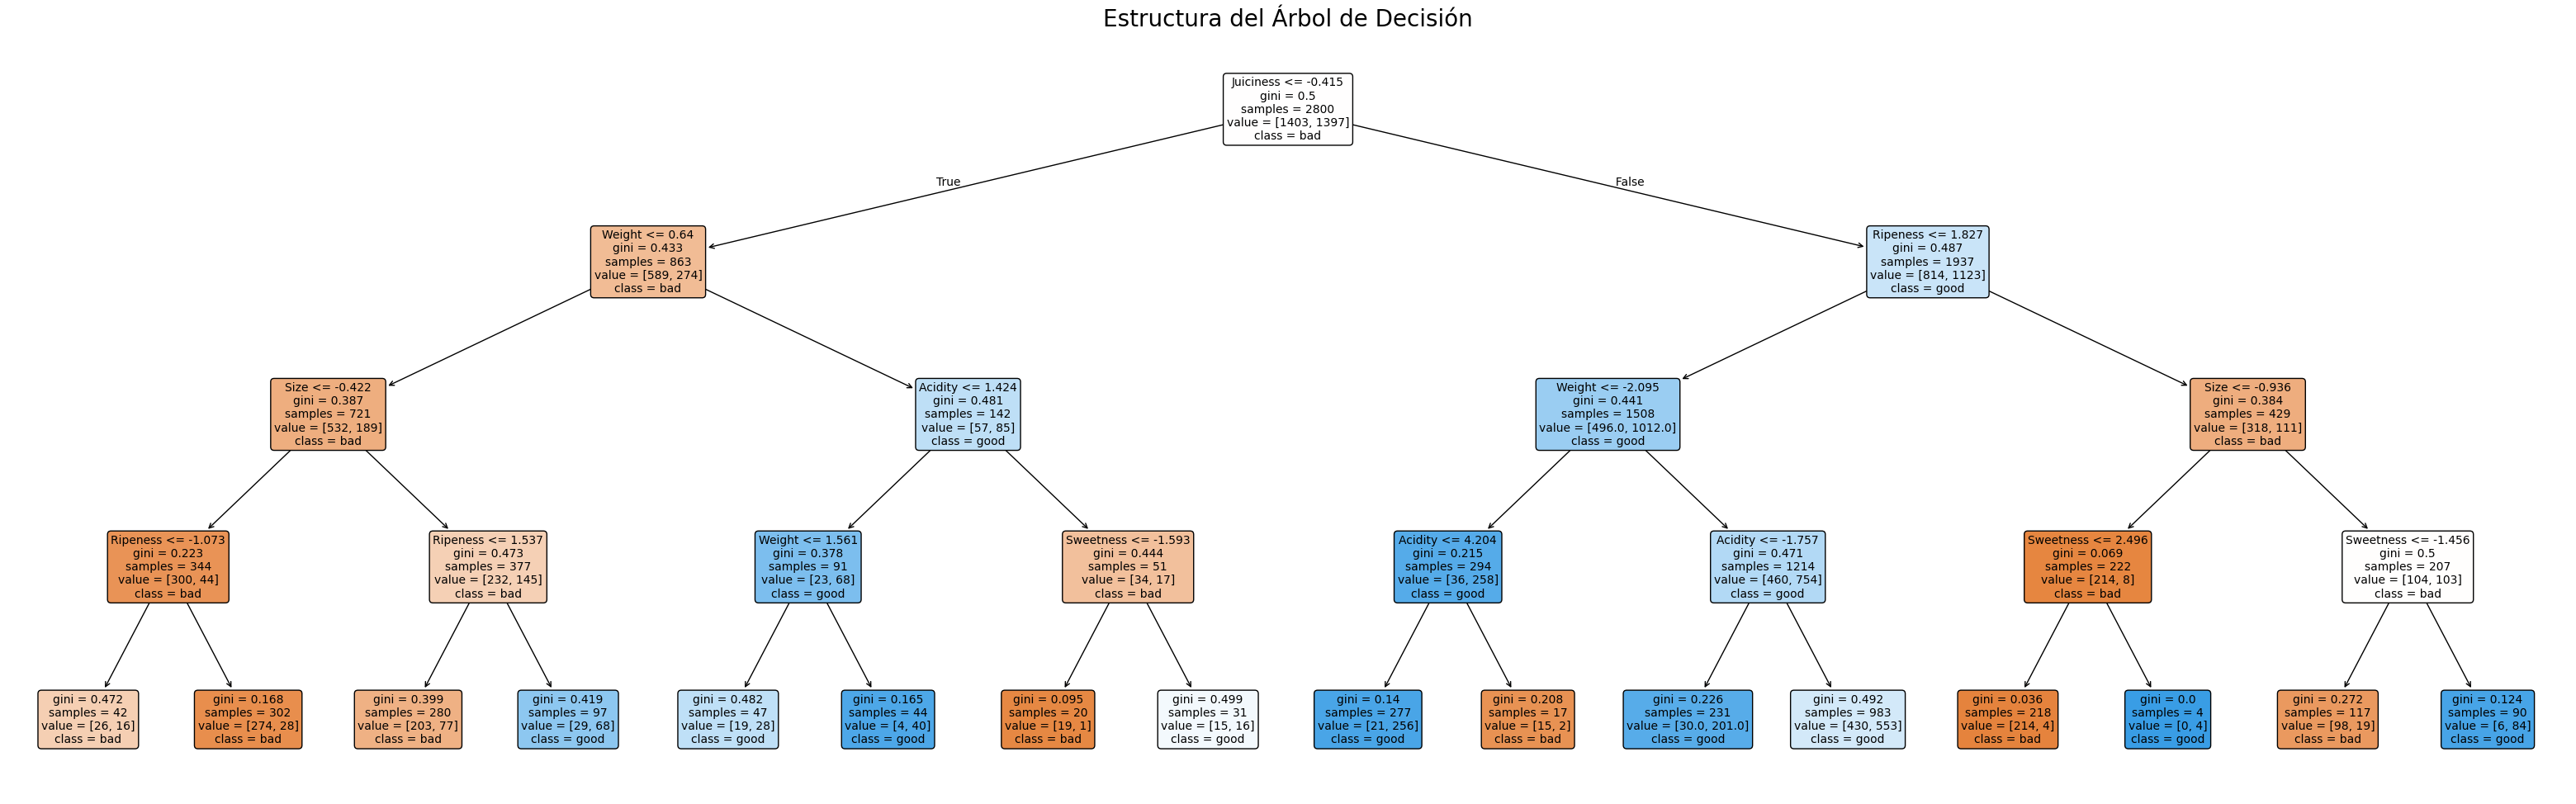

In [9]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

nombres_caracteristicas = ["A_id", "Size", "Weight", "Sweetness", "Crunchiness", "Juiciness", "Ripeness", "Acidity"]

plt.figure(figsize=(40, 12))
plot_tree(modelo_arbol,
          feature_names=nombres_caracteristicas,
          class_names=["bad", "good"],
          filled=True,
          rounded=True,
          fontsize=10)

plt.title("Estructura del Árbol de Decisión", fontsize=20)
plt.show()